In [13]:
# imports
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_samples
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet


# Data

In [14]:
"""
ONLY RUN THIS ONCE PER SESSION
    - Loading in Data with a delay to avoid making too many requests to the API
    - Use df to see whats loaded 
    - This was used to make the CSV file for the project, uncomment if you need additional data

BASE = "https://pokeapi.co/api/v2"

# Making the request
resp = requests.get(f"{BASE}/pokemon-species", params={"limit": 1025})
species_list = resp.json()["results"]

rows = []
for s in species_list:
    data = requests.get(s["url"]).json()
    time.sleep(0.1)
    # Grabbing the pokedex entry 
    entry = next(
        (f["flavor_text"].replace("\n", " ").replace("\f", " ")
         for f in data["flavor_text_entries"]
         if f["language"]["name"] == "en"),
        None,
    )

    genus = next(
        (g["genus"] for g in data["genera"] if g["language"]["name"] == "en"),
        None,
    )

    type_1, type_2 = None, None
    try:
        pk = requests.get(f"{BASE}/pokemon/{s['name']}").json()
        types = sorted(pk["types"], key=lambda t: t["slot"])
        type_1 = types[0]["type"]["name"] if len(types) > 0 else None
        type_2 = types[1]["type"]["name"] if len(types) > 1 else None
    except Exception:
        pass

    rows.append({
        "id": data["id"],
        "name": data["name"],
        "genus": genus,
        "type_1": type_1,
        "type_2": type_2,
        "color": data["color"]["name"],
        "generation": data["generation"]["name"],
        "pokedex_entry": entry,
    })

df = pd.DataFrame(rows).sort_values("id").reset_index(drop=True)
print(df.head())
df.to_csv("pokedex.csv", index=False)
"""

'\nONLY RUN THIS ONCE PER SESSION\n    - Loading in Data with a delay to avoid making too many requests to the API\n    - Use df to see whats loaded \n    - This was used to make the CSV file for the project, uncomment if you need additional data\n\nBASE = "https://pokeapi.co/api/v2"\n\n# Making the request\nresp = requests.get(f"{BASE}/pokemon-species", params={"limit": 1025})\nspecies_list = resp.json()["results"]\n\nrows = []\nfor s in species_list:\n    data = requests.get(s["url"]).json()\n    time.sleep(0.1)\n    # Grabbing the pokedex entry \n    entry = next(\n        (f["flavor_text"].replace("\n", " ").replace("\x0c", " ")\n         for f in data["flavor_text_entries"]\n         if f["language"]["name"] == "en"),\n        None,\n    )\n\n    genus = next(\n        (g["genus"] for g in data["genera"] if g["language"]["name"] == "en"),\n        None,\n    )\n\n    type_1, type_2 = None, None\n    try:\n        pk = requests.get(f"{BASE}/pokemon/{s[\'name\']}").json()\n        t

In [15]:
"""
Loading the non cleaned data into a dataframe
This version of the df is used to make our pre-analysis plots
"""

csv_files = [
    "../DATA/pokedex.csv",
]

df = pd.read_csv(csv_files[0])
df


,id,name,genus,type_1,type_2,color,generation,pokedex_entry
0,1,bulbasaur,Seed Pokémon,grass,poison,green,generation-i,A strange seed was planted on its back at birt...
1,2,ivysaur,Seed Pokémon,grass,poison,green,generation-i,"When the bulb on its back grows large, it appe..."
2,3,venusaur,Seed Pokémon,grass,poison,green,generation-i,The plant blooms when it is absorbing solar en...
3,4,charmander,Lizard Pokémon,fire,NaN,red,generation-i,"Obviously prefers hot places. When it rains, s..."
4,5,charmeleon,Flame Pokémon,fire,NaN,red,generation-i,"When it swings its burning tail, it elevates t..."
...,...,...,...,...,...,...,...,...
1020,1021,raging-bolt,Paradox Pokémon,electric,dragon,yellow,generation-ix,It's said to incinerate everything around it w...
1021,1022,iron-boulder,Paradox Pokémon,rock,psychic,gray,generation-ix,It resembles a Pokémon described in a dubious ...
1022,1023,iron-crown,Paradox Pokémon,steel,psychic,blue,generation-ix,It resembles a mysterious object introduced in...
1023,1024,terapagos,Tera Pokémon,normal,NaN,blue,generation-ix,Terapagos protects itself using its power to t...


# Exploritory plots 

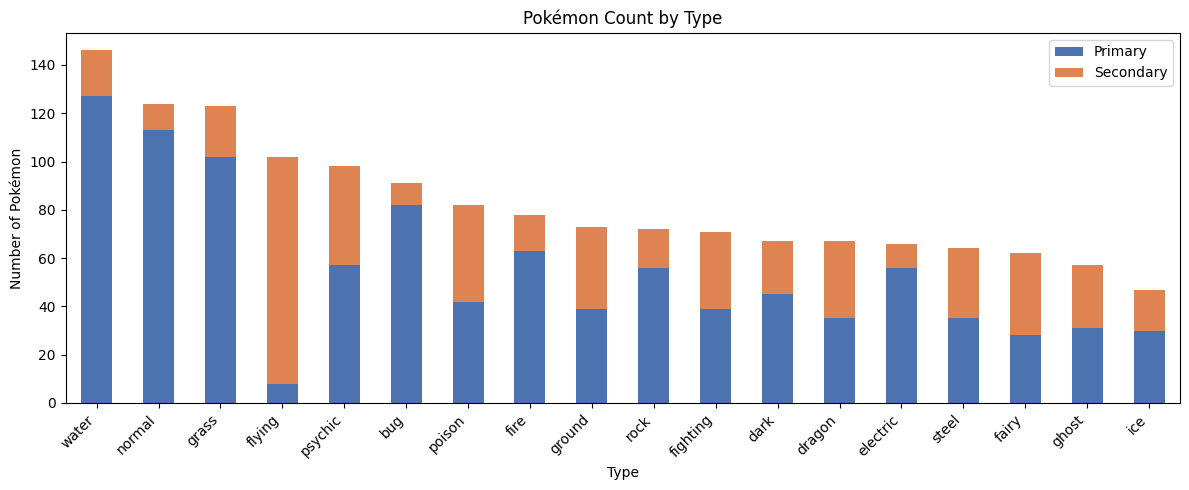

Missing type_1: 37


In [16]:
"""
From the df we gather both the primary and secondary types of the pokemon and count them.
We then plot the counts of each type in a stacked bar chart to visualize the distribution of types
finally we save the plot to the OUTPUT folder as a png file
"""

type_counts = pd.DataFrame({
    "Primary": df["type_1"].value_counts(),
    "Secondary": df["type_2"].value_counts(),
}).fillna(0)

type_counts = type_counts.loc[
    type_counts.sum(axis=1).sort_values(ascending=False).index
]

ax = type_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    color=["#4C72B0", "#DD8452"]
)

ax.set_title("Pokémon Count by Type")
ax.set_xlabel("Type")
ax.set_ylabel("Number of Pokémon")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save the plot
plt.savefig("../OUTPUT/pokemonTypeCounts.png", dpi=300, bbox_inches="tight")

plt.show()

print("Missing type_1:", df["type_1"].isna().sum())

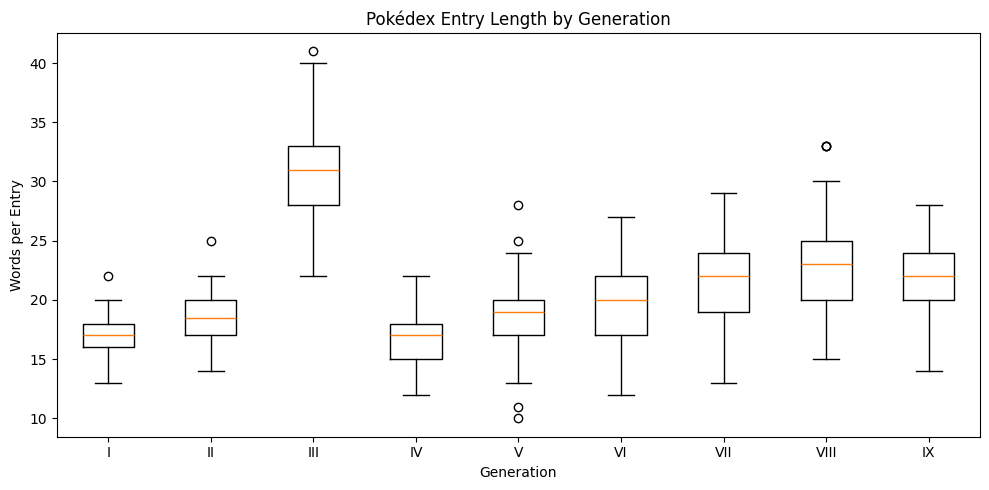

In [17]:
"""
Likewise we're looking at the length of the pokedex entries and plotting them by generation to see if there are any trends in the length of the entries 
then we save the plot to the OUTPUT folder as a png file
"""
entries = df.dropna(subset=["pokedex_entry"]).copy()
entries["entry_words"] = entries["pokedex_entry"].str.split().str.len()

# Order generations
gen_order = entries.groupby("generation")["id"].min().sort_values().index
labels = [g.split("-")[1].upper() for g in gen_order]
data = [entries.loc[entries["generation"] == g, "entry_words"] for g in gen_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data)
ax.set_xticklabels(labels)
ax.set_title("Pokédex Entry Length by Generation")
ax.set_xlabel("Generation")
ax.set_ylabel("Words per Entry")
plt.tight_layout()
plt.savefig("../OUTPUT/pokemonEntryLength.png", dpi=300, bbox_inches="tight")
plt.show()


# Cleaned Data 

In [18]:
"""
Below are some utility functions for normalizing data, calculating cosine distances, and loading matrices from CSV files.
These functions are useful for further analysis and clustering tasks.

The second group handles labels. The keys in MATRICES encode both the grouping and the
vocabulary size ("type50"), so these pull that apart and keep plot labels readable.
"""

def l2_normalize(X): #normlizing the data to make sure that the data is on the same scale and to avoid any bias in the analysis
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0 # guard against divide-by-zero on an all-zero row
    return X / norms


def cosine_distances(X): # calculating cosine distances between rows of a matrix so that we can use it for clustering and other analysis tasks
    d = np.clip(pdist(X, metric="cosine"), 0.0, 2.0) # clipped because float error can push values just past the valid range
    return d, squareform(d) # condensed form for linkage, square form for silhouette


def load_matrix(path, label_col): # loading a matrix from a CSV file and cleaning it
    df_clean = pd.read_csv(path)
    if label_col in df_clean.columns:
        df_clean = df_clean.set_index(label_col) # set the specified column as the index
    else:                                  # fall back to first column
        df_clean = df_clean.set_index(df_clean.columns[0]) # set the first column as the index
    df_clean.index = df_clean.index.astype(str) # keep row labels as text so they aren't read as numbers
    return df_clean.apply(pd.to_numeric, errors="coerce").fillna(0.0) # force word columns numeric, unparseable cells become 0


def parse_label(label): # splits a matrix key into its grouping and vocabulary size
    group = "type" if label.startswith("type") else "generation"
    suffix = label[len(group):]
    return group, int(suffix) if suffix else 150 # the unsuffixed keys are the 150-word matrices


GROUPS = ["type", "generation"] # the two groupings we cluster, each one at every vocabulary size


def group_labels(group): # all matrix keys for one grouping, ordered small to large vocabulary
    return sorted([l for l in MATRICES if parse_label(l)[0] == group],
                  key=lambda l: parse_label(l)[1])


def pretty(label, names): # turns raw row names into readable axis labels for the plots
    if parse_label(label)[0] == "generation":
        return ["Gen " + n.split("-")[1].upper() for n in names] # generation-iv -> Gen IV
    return [n.capitalize() for n in names]

In [19]:
#This is where we get the paths from our cleaned data files
MATRICES = {
    "type":       ("../DATA/pokemon_type-word_matrix.csv", "pokemon_type"),
    "generation": ("../DATA/pokemon_gen-word_matrix.csv",  "pokemon_gen"),
    "type50":       ("../DATA/pokemon_type-word_matrix50.csv", "pokemon_type"),
    "generation50": ("../DATA/pokemon_gen-word_matrix50.csv",  "pokemon_gen"),
    "type100":       ("../DATA/pokemon_type-word_matrix100.csv", "pokemon_type"),
    "generation100": ("../DATA/pokemon_gen-word_matrix100.csv",  "pokemon_gen"),
    "type200":       ("../DATA/pokemon_type-word_matrix200.csv", "pokemon_type"),
    "generation200": ("../DATA/pokemon_gen-word_matrix200.csv",  "pokemon_gen"),
}

In [20]:
"""
Loads every matrix listed in MATRICES, drops any row with no weight at all, and
precomputes the cosine distances used by the clustering cells below.

mats[label]  -> the cleaned DataFrame for that matrix
dists[label] -> (condensed distance vector, square distance matrix)
"""

mats, dists = {}, {}

for label, (path, label_col) in MATRICES.items():
    m = load_matrix(path, label_col)

    # A row of all zeros has no direction, so cosine distance is undefined for it.
    # Most likely at small vocabularies, where a type or generation may contribute no top words.
    dead = m.index[m.values.sum(axis=1) == 0].tolist()
    if dead:
        print(f"[{label}] dropping all-zero row(s): {dead}")
        m = m.drop(index=dead)

    X = l2_normalize(m.values.astype(float)) # unit rows, so distance reflects word mix rather than total weight
    d, Dsq = cosine_distances(X)
    mats[label], dists[label] = m, (d, Dsq)

    # Sanity check: rows x words, then the two distance shapes that should follow from it
    print(f"[{label}] matrix {m.shape}, condensed dist {d.shape}, square dist {Dsq.shape}")

# All matrices stacked into one frame, indexed by (matrix, label), purely for inspection.
# Vocabularies differ in size, so a word missing from a smaller matrix shows up as NaN here.
# Nothing downstream uses df_clean; the clustering reads mats and dists.
df_clean = pd.concat(mats, names=["matrix", "label"])
df_clean

[type] matrix (18, 150), condensed dist (153,), square dist (18, 18)
[generation] matrix (9, 150), condensed dist (36,), square dist (9, 9)
[type50] matrix (18, 50), condensed dist (153,), square dist (18, 18)
[generation50] matrix (9, 50), condensed dist (36,), square dist (9, 9)
[type100] matrix (18, 100), condensed dist (153,), square dist (18, 18)
[generation100] matrix (9, 100), condensed dist (36,), square dist (9, 9)
[type200] matrix (18, 200), condensed dist (153,), square dist (18, 18)
[generation200] matrix (9, 200), condensed dist (36,), square dist (9, 9)


silk     honey     cloak     swarm  \
matrix        label                                                     
type          bug              0.034409  0.020926  0.020646  0.020646   
              dark             0.000000  0.000000  0.000000  0.000000   
              dragon           0.000000  0.000000  0.000000  0.000000   
              electric         0.000000  0.000000  0.000000  0.000000   
              fairy            0.000000  0.000000  0.000000  0.000000   
...                                 ...       ...       ...       ...   
generation200 generation-ix    0.000000  0.000000  0.000000  0.000000   
              generation-v     0.000000  0.000000  0.000000  0.000000   
              generation-vi    0.000000  0.000000  0.000000  0.000000   
              generation-vii   0.000000  0.000000  0.000000  0.000000   
              generation-viii  0.000000  0.000000  0.000000  0.000000   

                                 flower    bubble      host      flap  \
matrix        label                                                     
type          bug              0.017906  0.015694  0.015694  0.012798   
              dark             0.000000  0.000000  0.000000  0.000000   
              dragon           0.000000  0.000000  0.000000  0.000000   
              electric         0.000000  0.000000  0.000000  0.000000   
              fairy            0.079511  0.000000  0.000000  0.000000   
...                                 ...       ...       ...       ...   
generation200 generation-ix    0.001913  0.000000  0.000000  0.000000   
              generation-v     0.001200  0.000000  0.000000  0.000000   
              generation-vi    0.010591  0.016837  0.000000  0.000000   
              generation-vii   0.005695  0.012675  0.000000  0.000000   
              generation-viii  0.000000  0.000000  0.000000  0.000000   

                                   bark  electricity  ...  warning    memory  \
matrix        label                                   ...                      
type          bug              0.010463     0.007162  ...      NaN       NaN   
              dark             0.000000     0.000000  ...      NaN       NaN   
              dragon           0.000000     0.010821  ...      NaN       NaN   
              electric         0.000000     0.139664  ...      NaN       NaN   
              fairy            0.000000     0.000000  ...      NaN       NaN   
...                                 ...          ...  ...      ...       ...   
generation200 generation-ix    0.000000     0.003825  ...      0.0  0.000000   
              generation-v     0.000000     0.002999  ...      0.0  0.006501   
              generation-vi    0.000000     0.000000  ...      0.0  0.000000   
              generation-vii   0.000000     0.000000  ...      0.0  0.000000   
              generation-viii  0.000000     0.004781  ...      0.0  0.000000   

                               pain   unleash  magnetic     beam  dubious  \
matrix        label                                                         
type          bug               NaN       NaN       NaN      NaN      NaN   
              dark              NaN       NaN       NaN      NaN      NaN   
              dragon            NaN       NaN       NaN      NaN      NaN   
              electric          NaN       NaN       NaN      NaN      NaN   
              fairy             NaN       NaN       NaN      NaN      NaN   
...                             ...       ...       ...      ...      ...   
generation200 generation-ix     0.0  0.000000       0.0  0.00691  0.00691   
              generation-v      0.0  0.000000       0.0  0.00000  0.00000   
              generation-vi     0.0  0.000000       0.0  0.00000  0.00000   
              generation-vii    0.0  0.012344       0.0  0.00000  0.00000   
              generation-viii   0.0  0.000000       0.0  0.00000  0.00000   

                               seas  swimm  capture  
matrix        label                   

# Analysis 

In [21]:
"""
Runs the hierarchical clustering itself, once per matrix in mats.

For each one: build the tree, score how faithfully it reproduces the original
distances, pick a cut by mean silhouette, and report the resulting clusters with
the words that define them.

hca[label] -> {"Z": linkage tree, "k": chosen cut, "clusters": membership,
               "sil": silhouette at every k, "coph": cophenetic correlation}
"""

LINKAGE = "average"   # Ward needs Euclidean distances; average linkage works with cosine


def pick_k(Z, Dsq):
    """Mean silhouette for every cut of the tree; returns the best k and all scores."""
    n = Dsq.shape[0]
    scores = {}
    for k in range(2, n):   # k = 1 and k = n have no silhouette defined
        labels_k = fcluster(Z, t=k, criterion="maxclust")
        # Tied merge distances can make maxclust return fewer clusters than asked for,
        # so only score cuts that actually split the rows into real groups.
        if 1 < len(np.unique(labels_k)) < n:
            scores[k] = silhouette_samples(Dsq, labels_k, metric="precomputed").mean()
    return max(scores, key=scores.get), scores   # highest mean silhouette wins


hca = {}

for label, m in mats.items():
    d, Dsq = dists[label]
    Z = linkage(d, method=LINKAGE)   # the tree, built on the condensed distances
    coph_r, _ = cophenet(Z, d)       # how well tree heights match the real distances; higher is better
    best_k, sil_scores = pick_k(Z, Dsq)

    # Cut the tree at the chosen k and attach the row names back to the cluster numbers
    clusters = pd.Series(fcluster(Z, t=best_k, criterion="maxclust"),
                         index=m.index, name="cluster")
    hca[label] = {"Z": Z, "k": best_k, "clusters": clusters,
                  "sil": sil_scores, "coph": coph_r}

    print(f"\n[{label}] cophenetic r = {coph_r:.3f} | best k = {best_k} "
          f"(mean silhouette {sil_scores[best_k]:.3f})")

    # For each cluster, average the TF-IDF weights of its members to see what drives it
    for c, members in clusters.groupby(clusters):
        top = m.loc[members.index].mean().sort_values(ascending=False).head(5)
        print(f"  cluster {c}: {', '.join(members.index)}")
        print(f"    top words: {', '.join(top[top > 0].index)}")   # drop zeros so singletons don't list empty words


[type] cophenetic r = 0.797 | best k = 6 (mean silhouette 0.099)
  cluster 1: fighting, poison
    top words: toxic, punch, gas, muscle, chain
  cluster 2: ice, water
    top words: snow, cold, freeze, breath, frigid
  cluster 3: dark, fire, ghost, ground
    top words: burn, spirit, sand, flame, bone
  cluster 4: normal, psychic, rock, steel
    top words: brain, ago, iron, salt, fossil
  cluster 5: bug, fairy, flying, grass
    top words: flower, scent, emit, flap, honey
  cluster 6: dragon, electric
    top words: electricity, lightning, apple, spark, tusk

[generation] cophenetic r = 0.793 | best k = 2 (mean silhouette 0.028)
  cluster 1: generation-i, generation-ii, generation-iii, generation-iv, generation-ix, generation-v, generation-vi, generation-viii
    top words: emit, magazine, cold, ears, paranormal
  cluster 2: generation-vii
    top words: ultra, balloon, intense, dangerous, wormhole

[type50] cophenetic r = 0.922 | best k = 8 (mean silhouette 0.251)
  cluster 1: bug, 

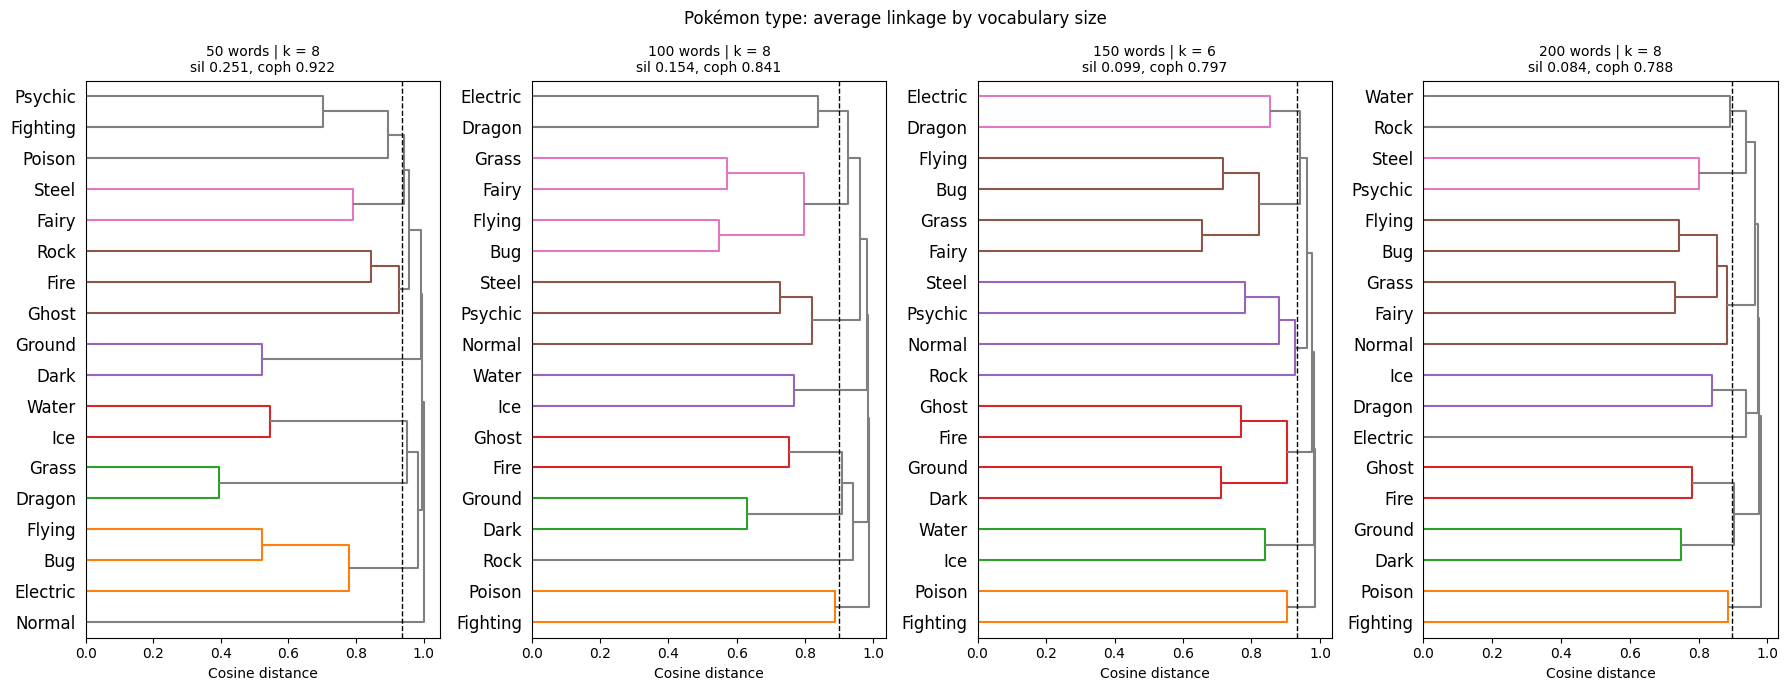

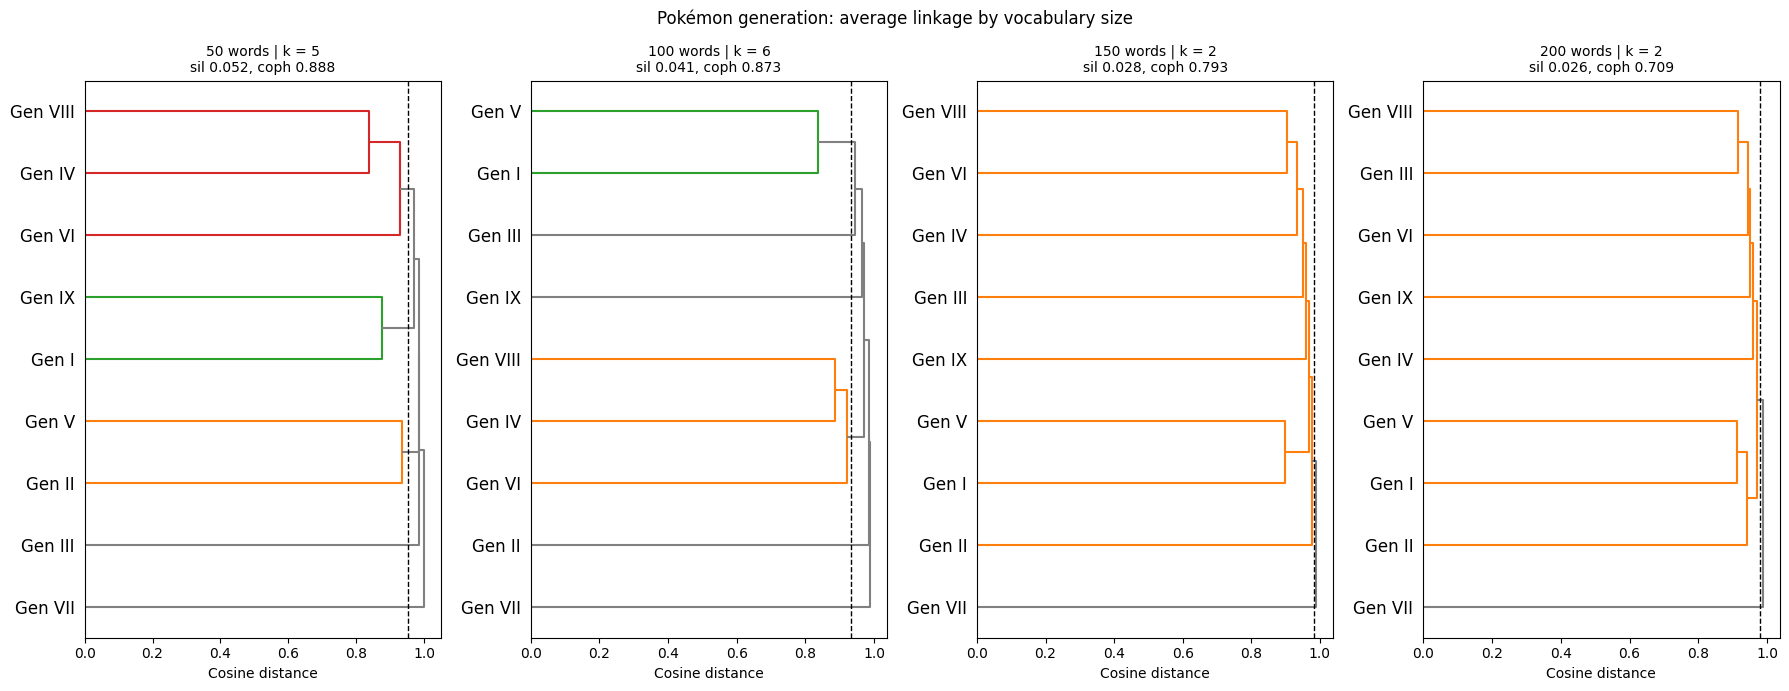

In [22]:
"""
Dendrogram for every matrix, one figure per grouping with a panel per vocabulary size.

Each tree is cut at its own chosen k: branches below the cut are colored by cluster,
everything above it is grey, and the dashed line marks where the cut falls.
"""

for group in GROUPS:
    labs = group_labels(group)   # small to large vocabulary, left to right
    fig, axes = plt.subplots(1, len(labs), figsize=(4.5 * len(labs), 7))

    for ax, label in zip(np.atleast_1d(axes), labs):   # atleast_1d so a single panel still iterates
        res = hca[label]
        Z, k = res["Z"], res["k"]

        # Put the cut between the last merge we keep and the first one we don't,
        # which leaves exactly k clusters colored
        cut = (Z[-k, 2] + Z[-(k - 1), 2]) / 2

        dendrogram(Z, labels=pretty(label, mats[label].index), orientation="right",
                   color_threshold=cut, above_threshold_color="grey", ax=ax)
        ax.axvline(cut, ls="--", c="k", lw=1)
        ax.set_title(f"{parse_label(label)[1]} words | k = {k}\n"
                     f"sil {res['sil'][k]:.3f}, coph {res['coph']:.3f}", fontsize=10)
        ax.set_xlabel("Cosine distance")   # leaves sit at 0, merges happen further right

    fig.suptitle(f"Pokémon {group}: {LINKAGE} linkage by vocabulary size")
    plt.tight_layout()
    plt.savefig(f"../OUTPUT/pokémon_{group}_{LINKAGE}.png", dpi=300, bbox_inches="tight")
    plt.show()

     type  generation  type50  generation50  type100  generation100  type200  \
k                                                                              
2   0.042       0.028   0.037         0.030    0.049          0.026    0.040   
3   0.050       0.015   0.072         0.020    0.074          0.020    0.054   
4   0.073       0.023   0.119         0.033    0.095          0.031    0.066   
5   0.088       0.021   0.169         0.052    0.120          0.034    0.080   
6   0.099       0.018   0.170         0.039    0.115          0.041    0.077   
7   0.083       0.019   0.237         0.035    0.127          0.031    0.071   
8   0.074       0.011   0.251         0.018    0.154          0.023    0.084   
9   0.091         NaN   0.245           NaN    0.145            NaN    0.071   
10  0.084         NaN   0.245           NaN    0.118            NaN    0.063   
11  0.061         NaN   0.239           NaN    0.100            NaN    0.052   
12  0.058         NaN   0.220           

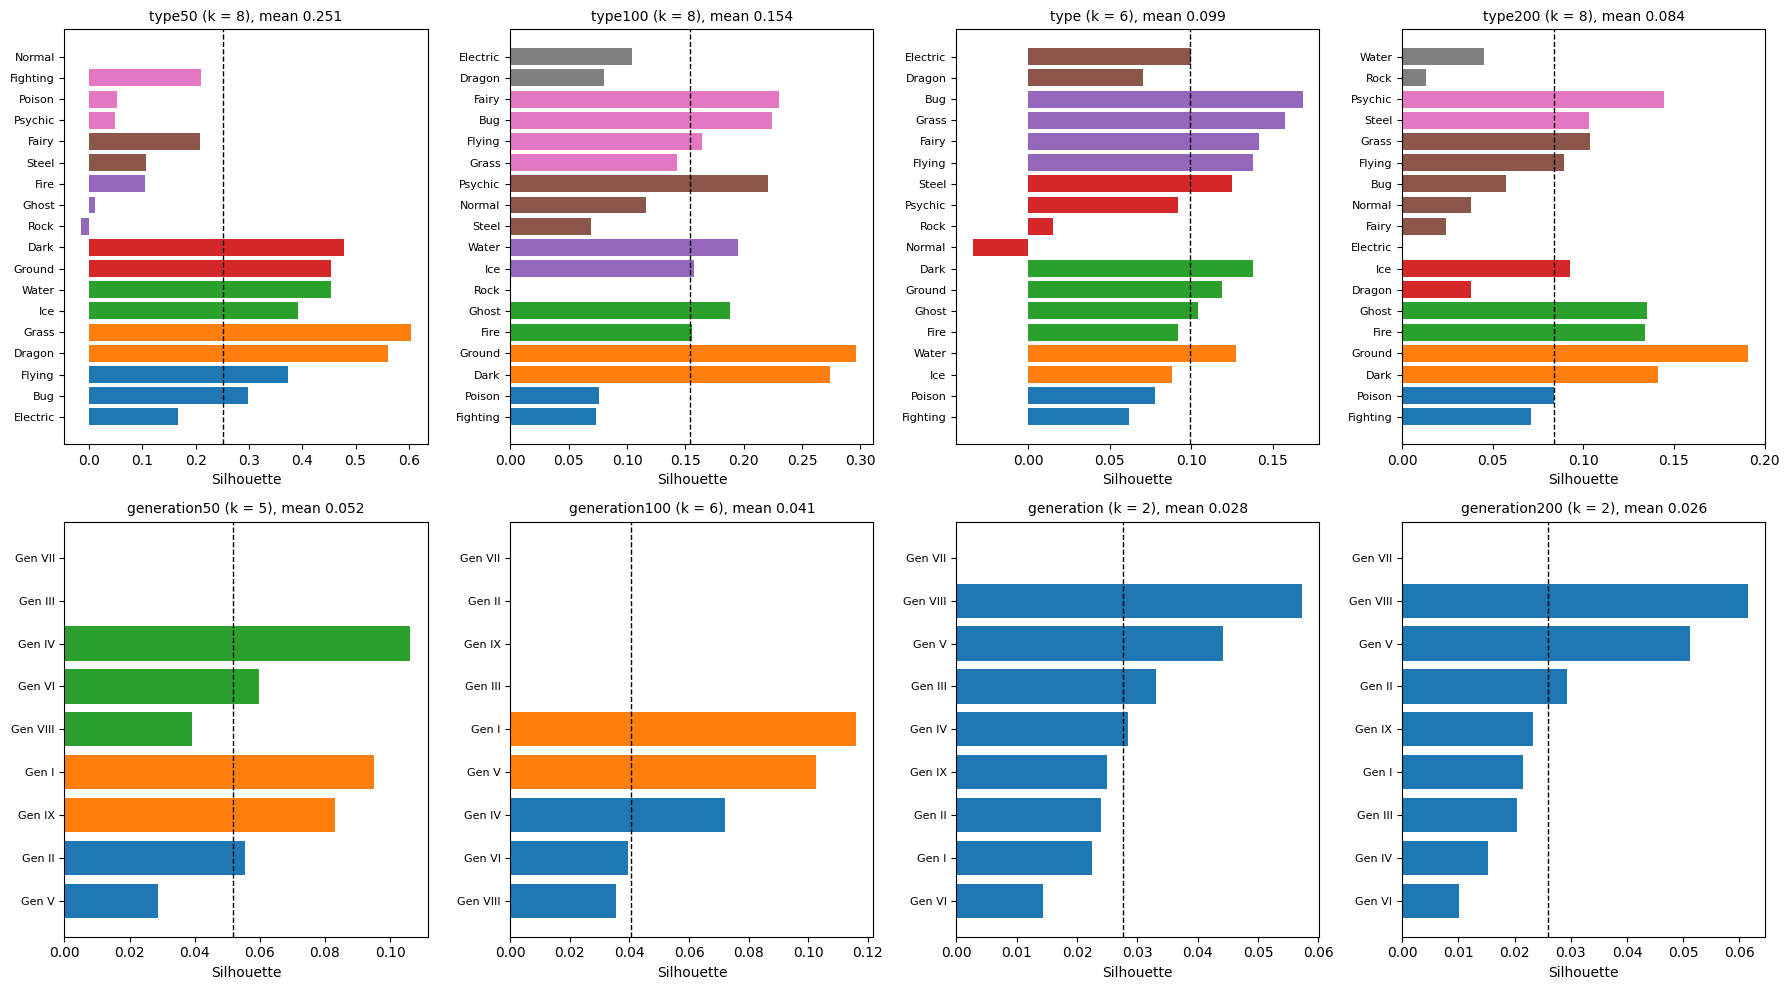

In [23]:
"""
Per-member silhouette for every matrix, at its own chosen k.

The printed table is the mean silhouette at every possible cut; the bars below show
how each individual type or generation scores inside the cluster it landed in.
Near zero means borderline, negative means it sits closer to a different cluster.
"""

# Mean silhouette at every cut, one column per matrix (NaN where a matrix has too few rows for that k)
sil_table = pd.DataFrame({label: res["sil"] for label, res in hca.items()})
sil_table.index.name = "k"
print(sil_table.round(3))

fig, axes = plt.subplots(2, 4, figsize=(18, 10))   # one row per grouping, one column per vocabulary size

for row, group in enumerate(GROUPS):
    for col, label in enumerate(group_labels(group)):
        ax, res = axes[row, col], hca[label]
        clusters, (d, Dsq) = res["clusters"], dists[label]

        # Silhouette per row, computed straight from the distance matrix we already built
        s = pd.Series(silhouette_samples(Dsq, clusters.values, metric="precomputed"),
                      index=clusters.index, name="silhouette")
        # Group the bars by cluster, then sort within each so the weakest member sits at the bottom
        order = pd.concat([clusters, s], axis=1).sort_values(["cluster", "silhouette"])

        ax.barh(range(len(order)), order["silhouette"],
                color=plt.cm.tab10((order["cluster"].values - 1) % 10))   # cluster numbers start at 1
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels(pretty(label, order.index), fontsize=8)
        ax.axvline(s.mean(), ls="--", c="k", lw=1)   # the mean, for comparison against each bar
        ax.set_xlabel("Silhouette")
        ax.set_title(f"{label} (k = {res['k']}), mean {s.mean():.3f}", fontsize=10)

        print(f"\n[{label}] per-member silhouette\n{order.round(3)}")

plt.tight_layout()
plt.savefig("../OUTPUT/silhouette_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

                    group  vocab  rows  words  best_k  mean_silhouette  \
generation50   generation     50     9     50       5            0.052   
generation100  generation    100     9    100       6            0.041   
generation     generation    150     9    150       2            0.028   
generation200  generation    200     9    200       2            0.026   
type50               type     50    18     50       8            0.251   
type100              type    100    18    100       8            0.154   
type                 type    150    18    150       6            0.099   
type200              type    200    18    200       8            0.084   

               cophenetic_r             cluster_sizes  
generation50          0.888           [2, 2, 3, 1, 1]  
generation100         0.873        [3, 2, 1, 1, 1, 1]  
generation            0.793                    [8, 1]  
generation200         0.709                    [8, 1]  
type50                0.922  [3, 2, 2, 2, 3, 2, 3, 1]

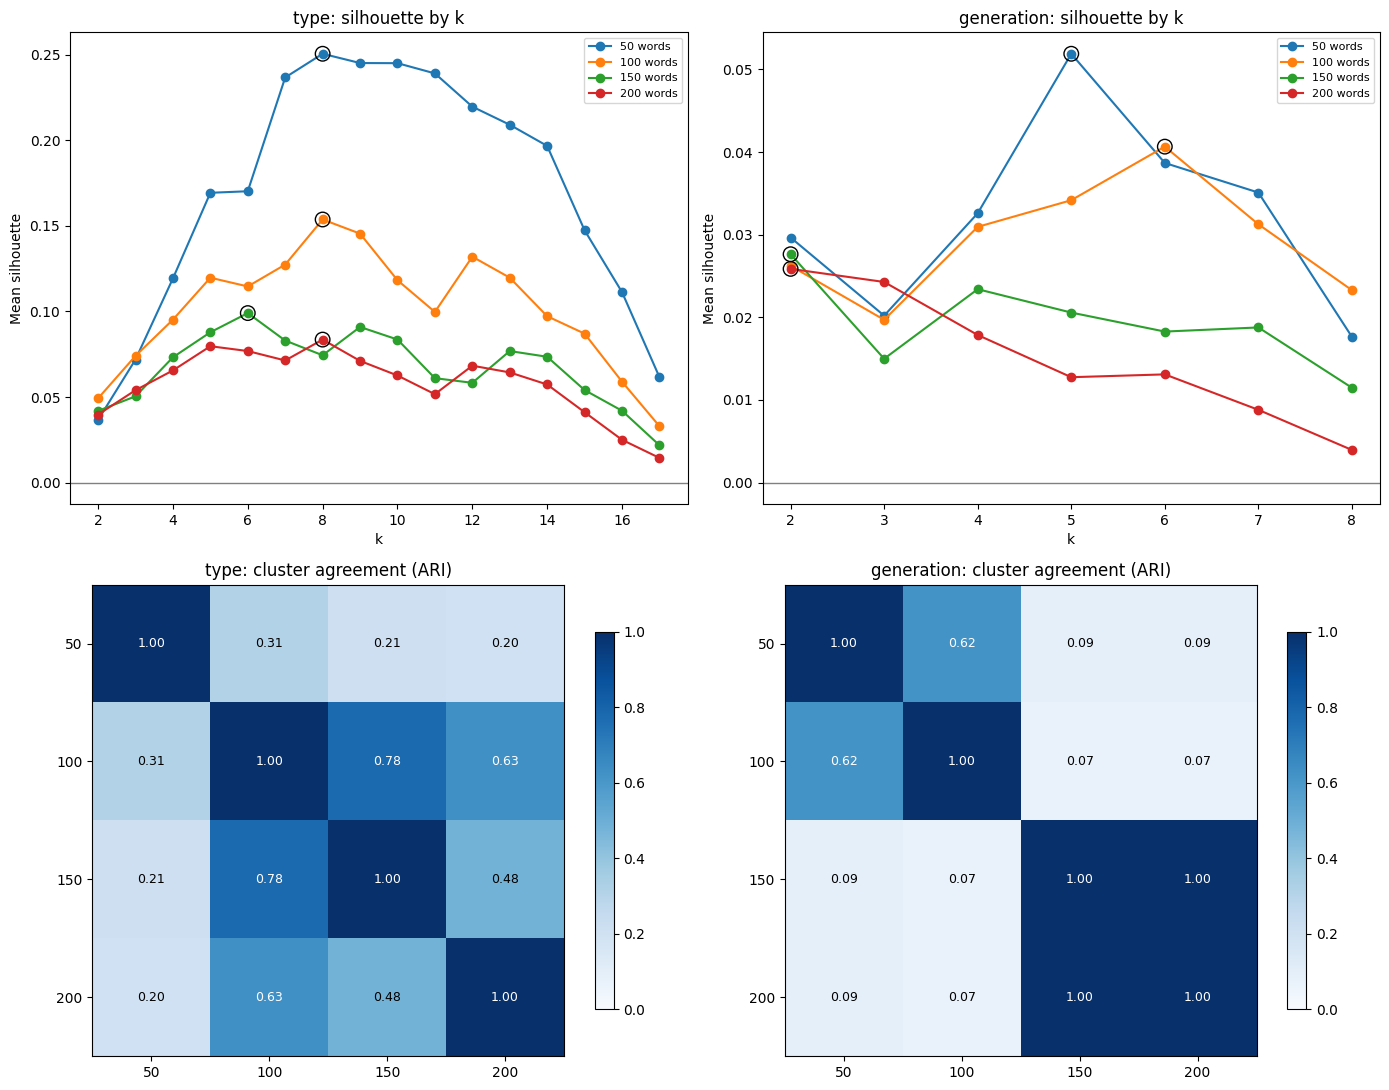

In [24]:
"""
Compares the eight runs against each other rather than reading them one at a time.

summary lines up the headline numbers; the top row of the figure overlays the
silhouette curves for every vocabulary size within a grouping; the bottom row scores
how much the actual cluster memberships agree across vocabulary sizes.
"""

from sklearn.metrics import adjusted_rand_score

# One row per matrix, sorted so each grouping runs small to large vocabulary
summary = pd.DataFrame([{
    "group": parse_label(l)[0],
    "vocab": parse_label(l)[1],
    "rows": mats[l].shape[0],          # smaller than expected means an all-zero row got dropped
    "words": mats[l].shape[1],
    "best_k": r["k"],
    "mean_silhouette": r["sil"][r["k"]],
    "cophenetic_r": r["coph"],
    "cluster_sizes": r["clusters"].value_counts().sort_index().tolist(),   # watch for a pile of singletons
} for l, r in hca.items()], index=list(hca)).sort_values(["group", "vocab"])

print(summary.round(3))


def ari_matrix(group):
    """Pairwise cluster agreement between vocabulary sizes, at each one's own best k.
    1.0 is identical grouping, 0.0 is no better than chance."""
    labs = group_labels(group)
    M = pd.DataFrame(index=labs, columns=labs, dtype=float)
    for a in labs:
        for b in labs:
            ca, cb = hca[a]["clusters"], hca[b]["clusters"]
            common = ca.index.intersection(cb.index)   # a small vocab may have dropped an all-zero row
            M.loc[a, b] = adjusted_rand_score(ca[common], cb[common])
    return M


fig, axes = plt.subplots(2, 2, figsize=(14, 11))   # columns are groupings, rows are the two comparisons

for col, group in enumerate(GROUPS):
    # Top: silhouette curves, all vocabulary sizes on shared axes
    ax = axes[0, col]
    for label in group_labels(group):
        res = hca[label]
        ax.plot(list(res["sil"]), list(res["sil"].values()), marker="o",
                label=f"{parse_label(label)[1]} words")
        ax.scatter([res["k"]], [res["sil"][res["k"]]], s=110,
                   facecolors="none", edgecolors="k", zorder=3)   # circles the chosen k
    ax.axhline(0, c="grey", lw=1)
    ax.set_xlabel("k")
    ax.set_ylabel("Mean silhouette")
    ax.set_title(f"{group}: silhouette by k")
    ax.legend(fontsize=8)

    # Bottom: do the vocabulary sizes actually put the same members together?
    A = ari_matrix(group)
    ax = axes[1, col]
    im = ax.imshow(A.values.astype(float), vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks(range(len(A)))
    ax.set_xticklabels([parse_label(l)[1] for l in A.columns])
    ax.set_yticks(range(len(A)))
    ax.set_yticklabels([parse_label(l)[1] for l in A.index])
    for i in range(len(A)):
        for j in range(len(A)):
            v = A.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v > 0.6 else "black", fontsize=9)   # flip text color on dark cells
    ax.set_title(f"{group}: cluster agreement (ARI)")
    fig.colorbar(im, ax=ax, shrink=0.8)

    print(f"\n[{group}] ARI\n{A.round(2)}")

plt.tight_layout()
plt.savefig("../OUTPUT/pokemon_ARI.png", dpi=300, bbox_inches="tight")
plt.show()